In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train = pd.read_csv("../data/raw/train.csv")
train['MSSubClass'] = train['MSSubClass'].astype(str)  # from Phase 3

numerical_features = train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = train.select_dtypes(include=['object']).columns.tolist()
numerical_features_only = [c for c in numerical_features if c not in ['Id', 'SalePrice']]

sns.set_style("whitegrid")

/var/folders/xd/r1tqvb4s2bvd6gpjtvvbp53r0000gn/T/ipykernel_3984/57356236.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = train.select_dtypes(include=['object']).columns.tolist()


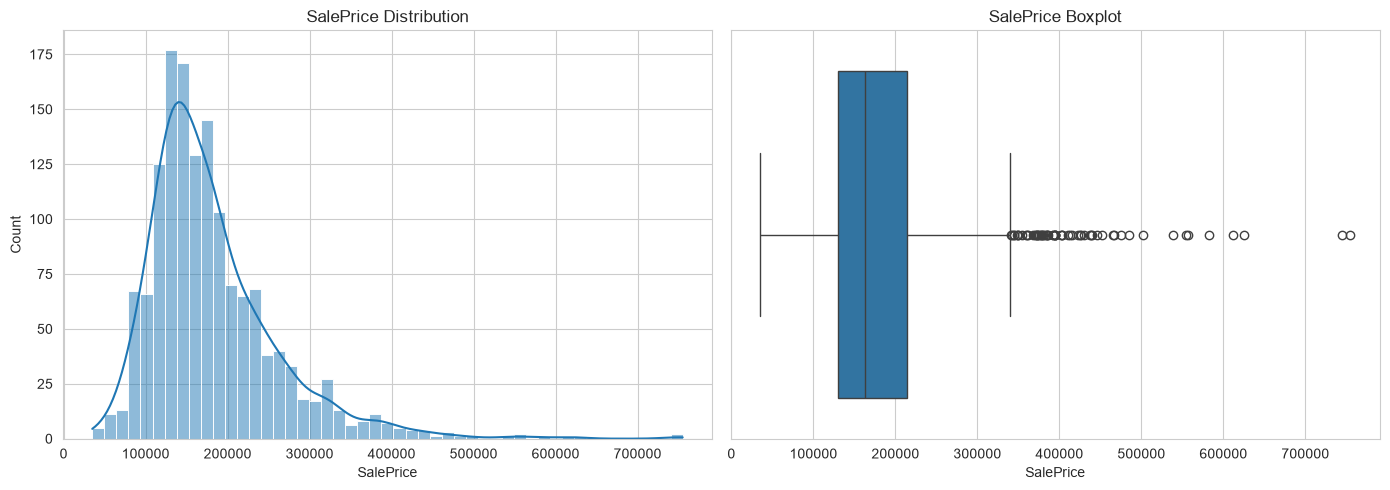

Skewness: 1.8828757597682129


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(train['SalePrice'], kde=True, ax=axes[0])
axes[0].set_title("SalePrice Distribution")

sns.boxplot(x=train['SalePrice'], ax=axes[1])
axes[1].set_title("SalePrice Boxplot")

plt.tight_layout()
plt.show()

print("Skewness:", train['SalePrice'].skew())

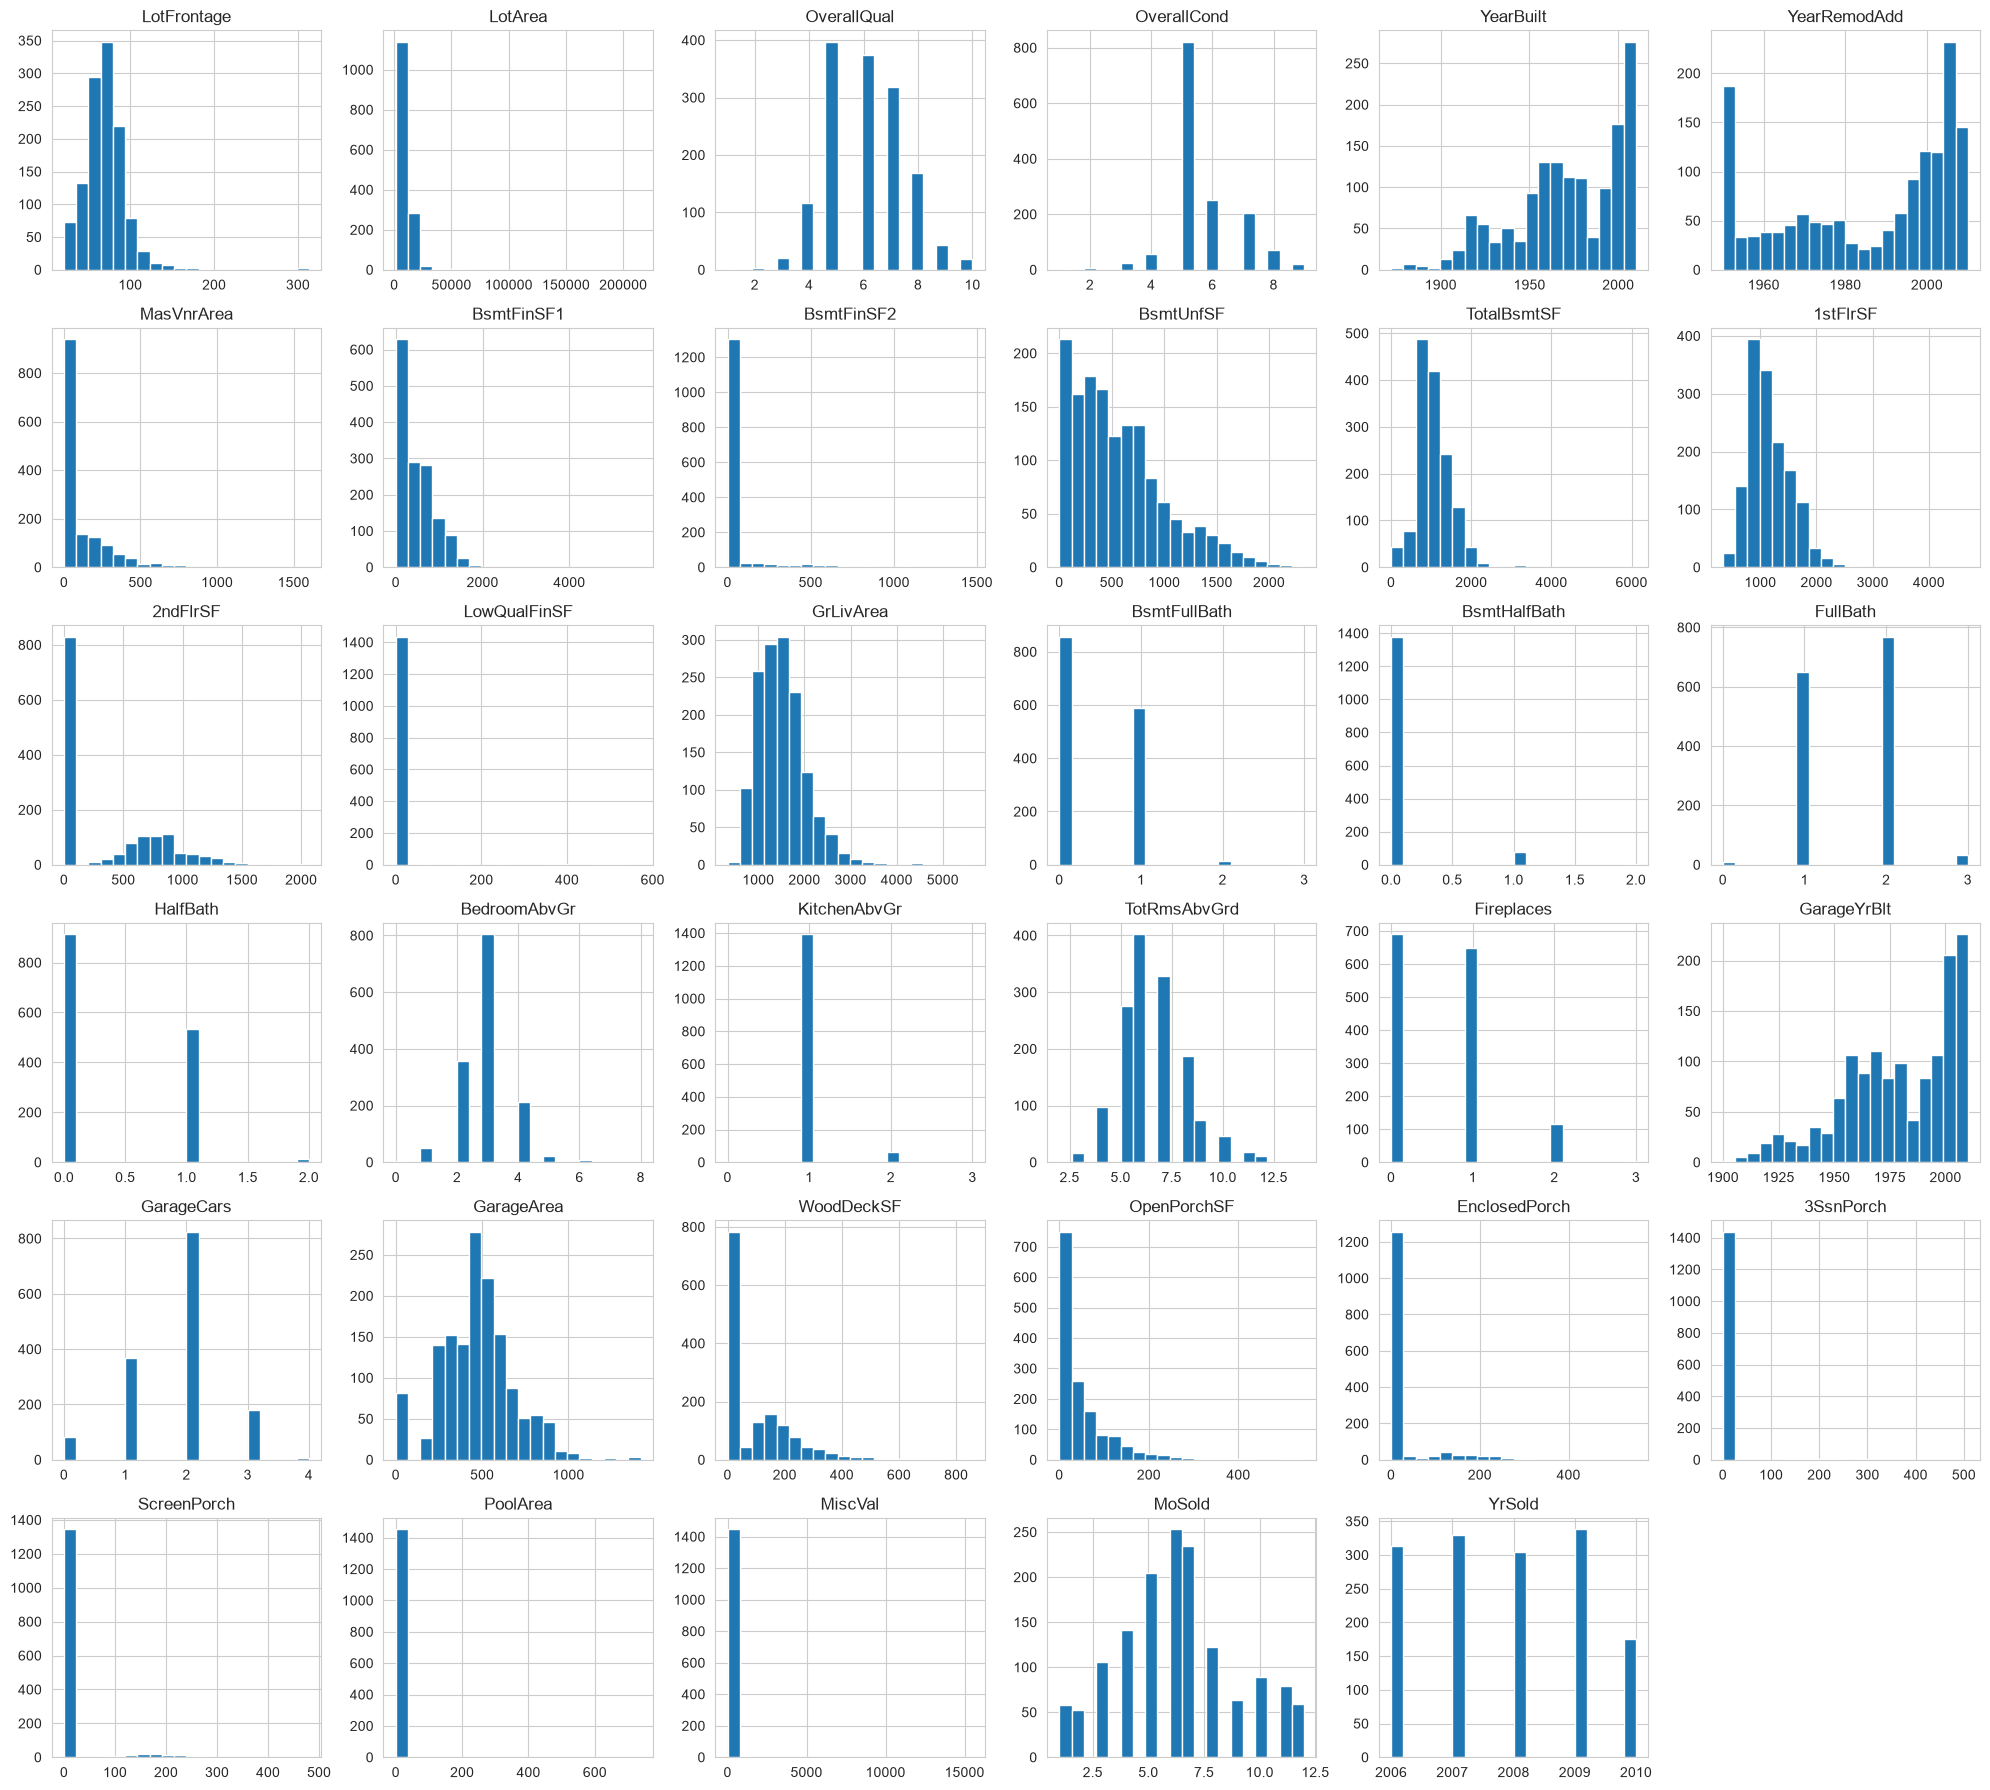

In [3]:
train[numerical_features_only].hist(bins=20, figsize=(20, 18))
plt.tight_layout()
plt.show()

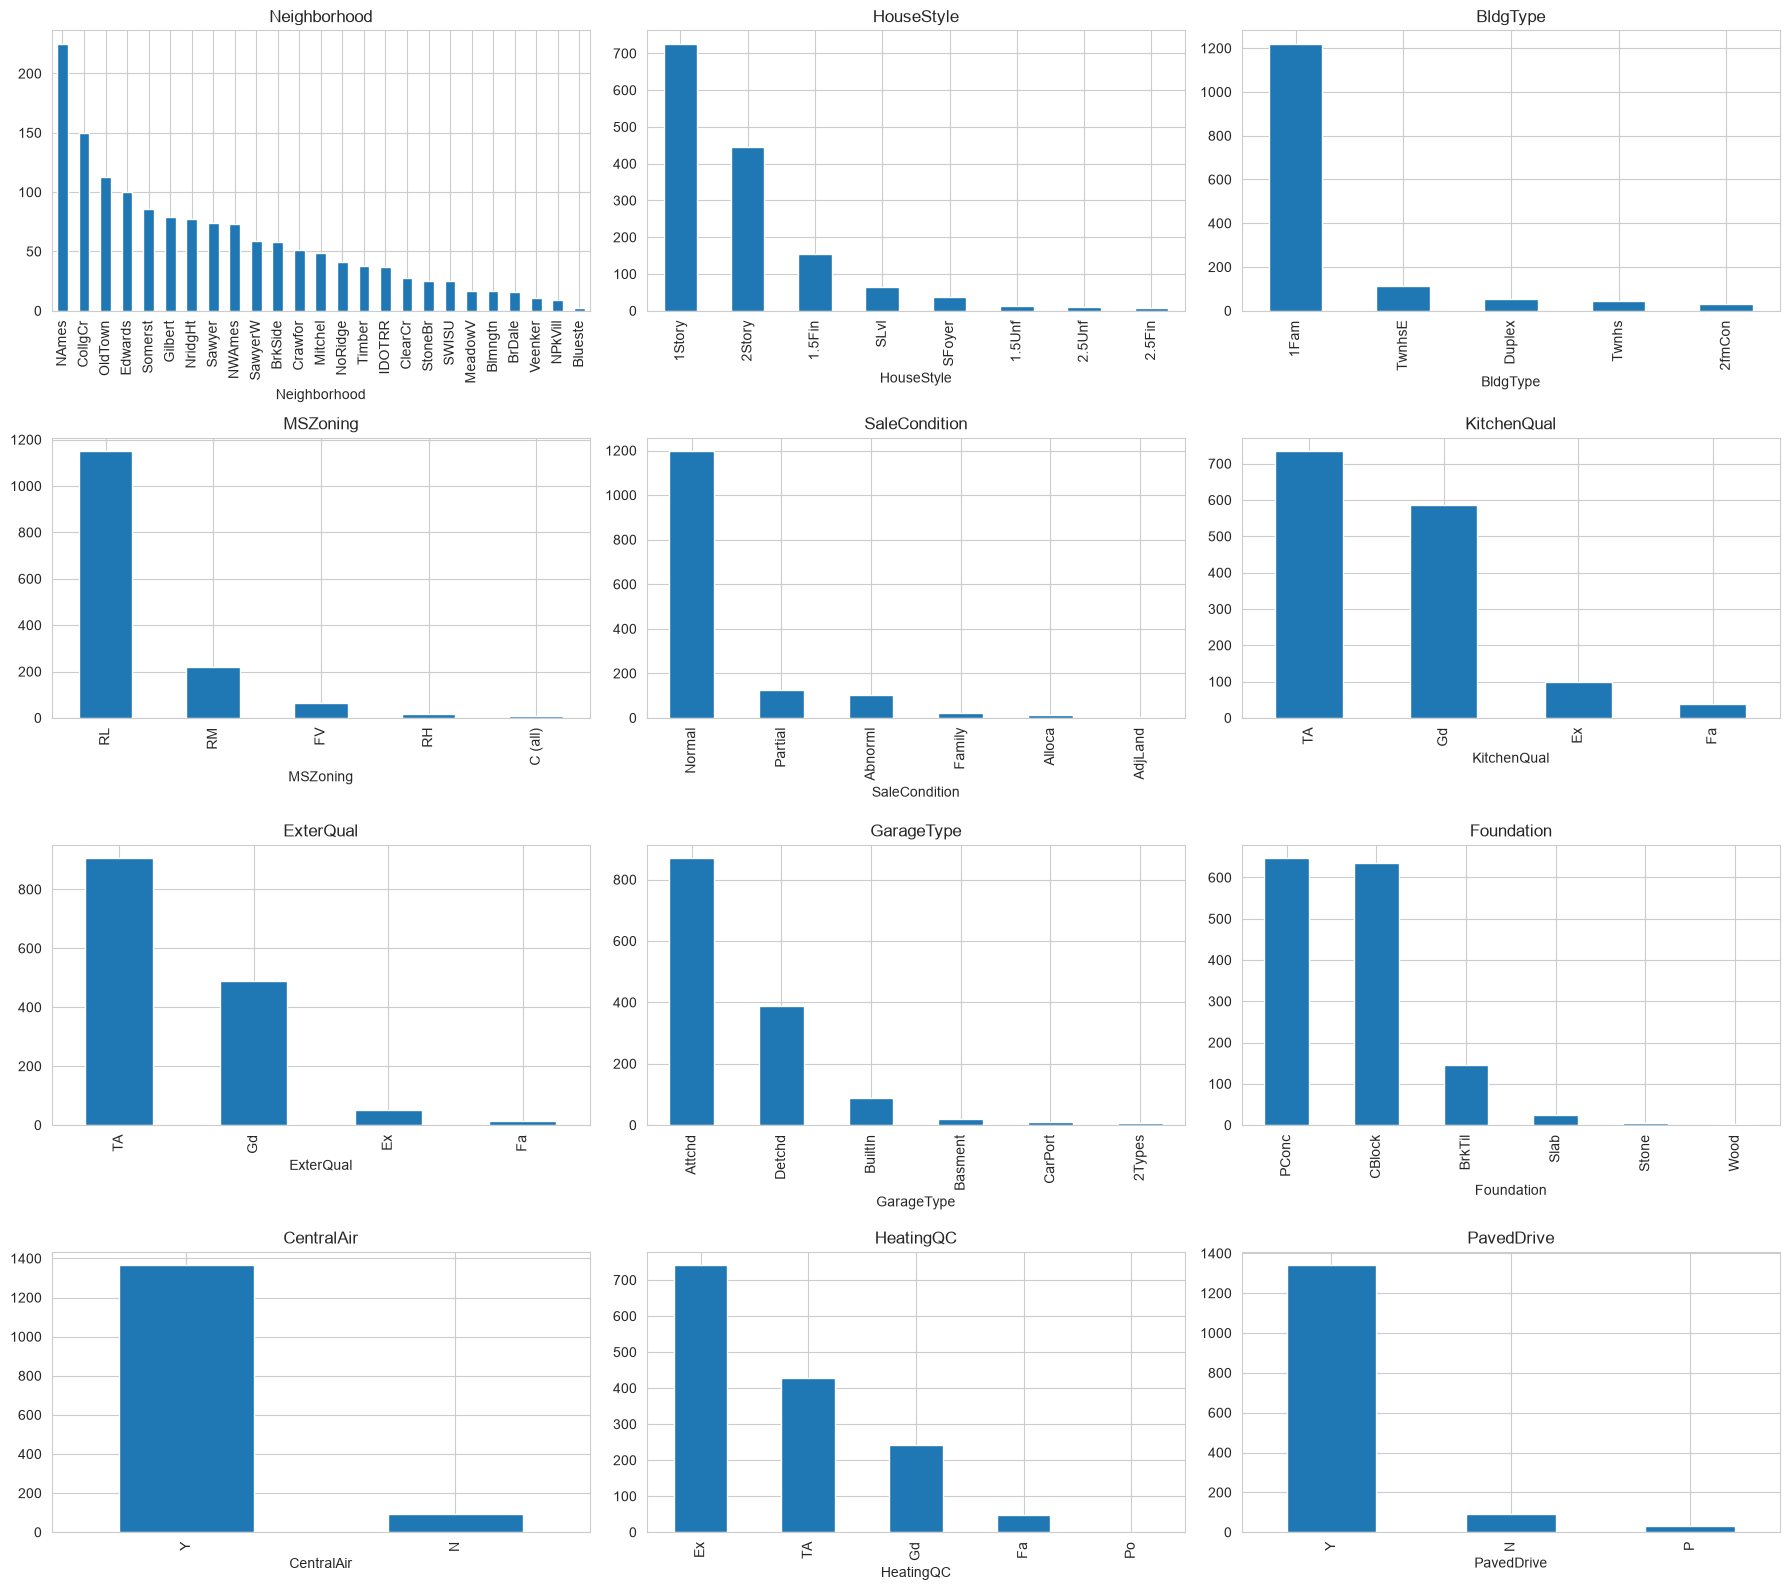

In [4]:
fig, axes = plt.subplots(4, 3, figsize=(18, 16))
axes = axes.flatten()

top_cats = ['Neighborhood', 'HouseStyle', 'BldgType', 'MSZoning',
            'SaleCondition', 'KitchenQual', 'ExterQual', 'GarageType',
            'Foundation', 'CentralAir', 'HeatingQC', 'PavedDrive']

for i, col in enumerate(top_cats):
    train[col].value_counts().plot(kind='bar', ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

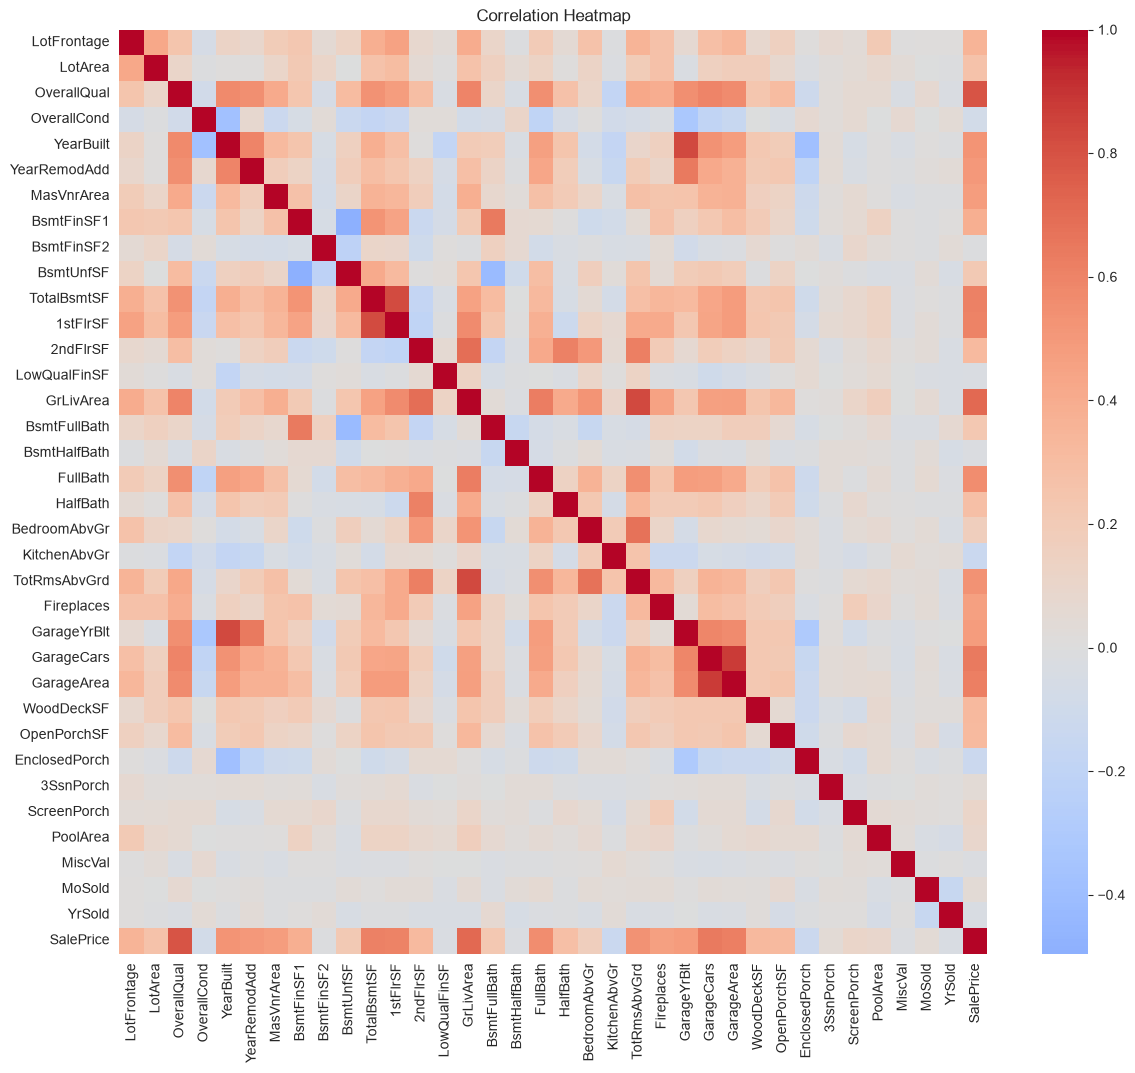

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64


In [5]:
plt.figure(figsize=(14, 12))
corr = train[numerical_features_only + ['SalePrice']].corr()
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False)
plt.title("Correlation Heatmap")
plt.show()

# Top correlated features with SalePrice
top_corr = corr['SalePrice'].sort_values(ascending=False)
print(top_corr.head(15))

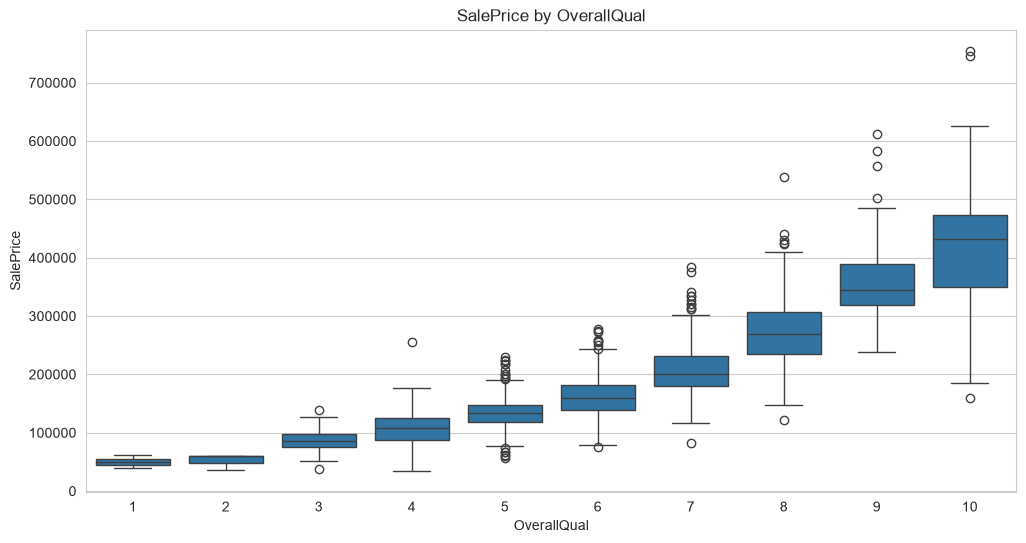

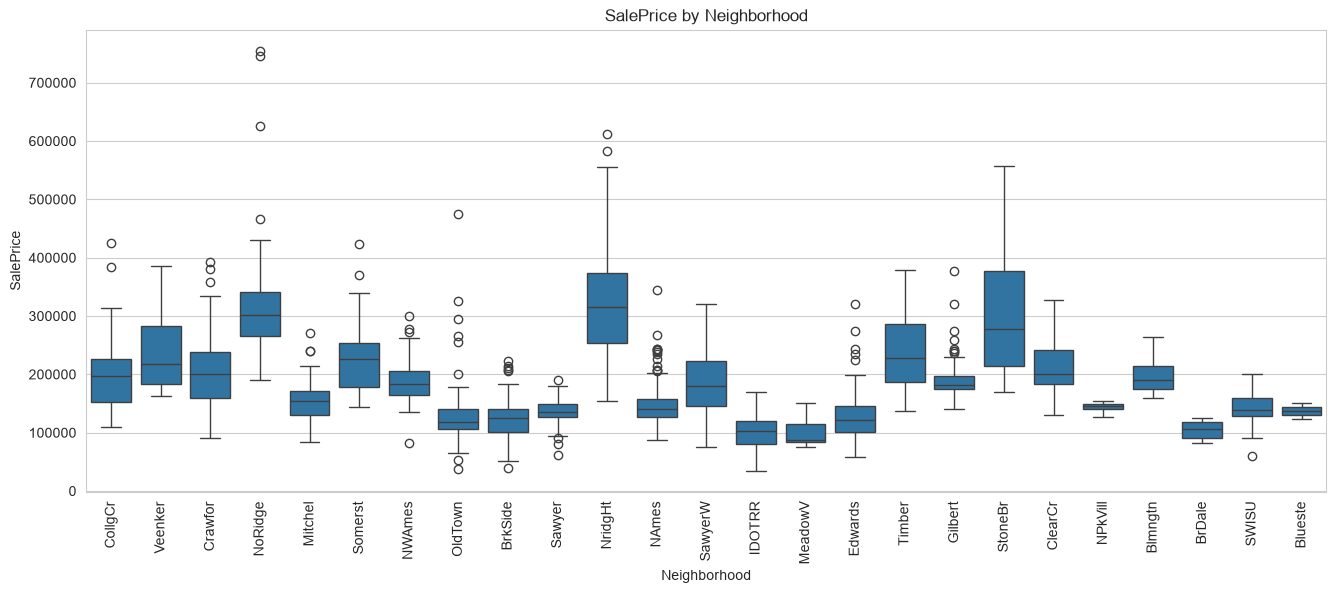

In [6]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='OverallQual', y='SalePrice', data=train)
plt.title("SalePrice by OverallQual")
plt.show()

plt.figure(figsize=(16, 6))
sns.boxplot(x='Neighborhood', y='SalePrice', data=train)
plt.xticks(rotation=90)
plt.title("SalePrice by Neighborhood")
plt.show()

In [7]:
skewed = train[numerical_features_only].skew().sort_values(ascending=False)
print(skewed.head(15))

MiscVal          24.476794
PoolArea         14.828374
LotArea          12.207688
3SsnPorch        10.304342
LowQualFinSF      9.011341
KitchenAbvGr      4.488397
BsmtFinSF2        4.255261
ScreenPorch       4.122214
BsmtHalfBath      4.103403
EnclosedPorch     3.089872
MasVnrArea        2.669084
OpenPorchSF       2.364342
LotFrontage       2.163569
BsmtFinSF1        1.685503
WoodDeckSF        1.541376
dtype: float64
